# Stock Price Predictor (LSTM)

This notebook is split into clean runnable cells:
1. Imports and settings
2. Helper functions
3. Model builder
4. Train + test pipeline
5. Plot + next-day prediction

In [1]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Config (change these if needed)
TICKER = "GOOG"
TRAIN_START = dt.datetime(2014, 1, 1)
TRAIN_END = dt.datetime(2023, 1, 1)
TEST_START = TRAIN_END
TEST_END = dt.datetime.now()

PREDICTION_DAYS = 60
LSTM_UNITS = 50
DROPOUT_RATE = 0.2
BATCH_SIZE = 32
EPOCHS = 5  # use 1 for quick smoke test

In [2]:
def get_close_series(df: pd.DataFrame) -> pd.Series:
    """Extract Close prices, handling both regular and MultiIndex yfinance columns."""
    if df.empty:
        raise ValueError("No stock data found. Check ticker symbol/date range.")

    if isinstance(df.columns, pd.MultiIndex):
        if "Close" not in df.columns.get_level_values(0):
            raise ValueError("'Close' column not found in downloaded data.")
        close_df = df.xs("Close", axis=1, level=0)
        return close_df.iloc[:, 0] if isinstance(close_df, pd.DataFrame) else close_df

    if "Close" not in df.columns:
        raise ValueError("'Close' column not found in downloaded data.")
    return df["Close"]


def fetch_close(ticker: str, start: dt.datetime, end: dt.datetime) -> pd.Series:
    data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    return get_close_series(data)


def build_sequences(scaled_values: np.ndarray, window: int):
    x, y = [], []
    for i in range(window, len(scaled_values)):
        x.append(scaled_values[i - window:i, 0])
        y.append(scaled_values[i, 0])
    x = np.array(x)
    y = np.array(y)
    x = np.reshape(x, (x.shape[0], x.shape[1], 1))
    return x, y


def evaluate(actual: np.ndarray, predicted: np.ndarray) -> dict:
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}

In [3]:
def build_model(window: int):
    model = keras.models.Sequential([
        keras.layers.Input(shape=(window, 1)),
        keras.layers.LSTM(units=LSTM_UNITS, return_sequences=True),
        keras.layers.Dropout(DROPOUT_RATE),
        keras.layers.LSTM(units=LSTM_UNITS, return_sequences=True),
        keras.layers.Dropout(DROPOUT_RATE),
        keras.layers.LSTM(units=LSTM_UNITS),
        keras.layers.Dropout(DROPOUT_RATE),
        keras.layers.Dense(units=1),
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

In [4]:
# 1) Load train/test data
close_train = fetch_close(TICKER, TRAIN_START, TRAIN_END)
close_test = fetch_close(TICKER, TEST_START, TEST_END)

# 2) Scale training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(close_train.values.reshape(-1, 1))

# 3) Build train sequences
x_train, y_train = build_sequences(scaled_train, PREDICTION_DAYS)
print("x_train shape:", x_train.shape)

# 4) Train model
model = build_model(PREDICTION_DAYS)
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

# 5) Prepare test sequences
combined = pd.concat((close_train, close_test), axis=0)
inputs_for_model = combined.iloc[-(len(close_test) + PREDICTION_DAYS):].values.reshape(-1, 1)
inputs_for_model = scaler.transform(inputs_for_model)

x_test, _ = build_sequences(inputs_for_model, PREDICTION_DAYS)

# 6) Predict and inverse-scale
predicted_scaled = model.predict(x_test, verbose=0)
predicted_prices = scaler.inverse_transform(predicted_scaled).flatten()
actual_prices = close_test.values

# Safe alignment
n = min(len(actual_prices), len(predicted_prices))
actual_prices = actual_prices[:n]
predicted_prices = predicted_prices[:n]
test_dates = close_test.index[:n]

metrics = evaluate(actual_prices, predicted_prices)
metrics

x_train shape: (2206, 60, 1)


2026-04-20 21:15:33.940594: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-20 21:15:33.940637: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-20 21:15:33.940648: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-20 21:15:33.940672: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-20 21:15:33.940689: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/5


2026-04-20 21:15:35.168191: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 1/69 ━━━━━━━━━━━━━━━━━━━━ 4:23 4s/step - loss: 0.0967

...

61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0030

64/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0029

67/69 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0029

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0025


{'MAE': 18.591866389313854,
 'RMSE': 30.083657958201197,
 'MAPE (%)': 8.147069532949445,
 'R2': 0.7792973334101404}

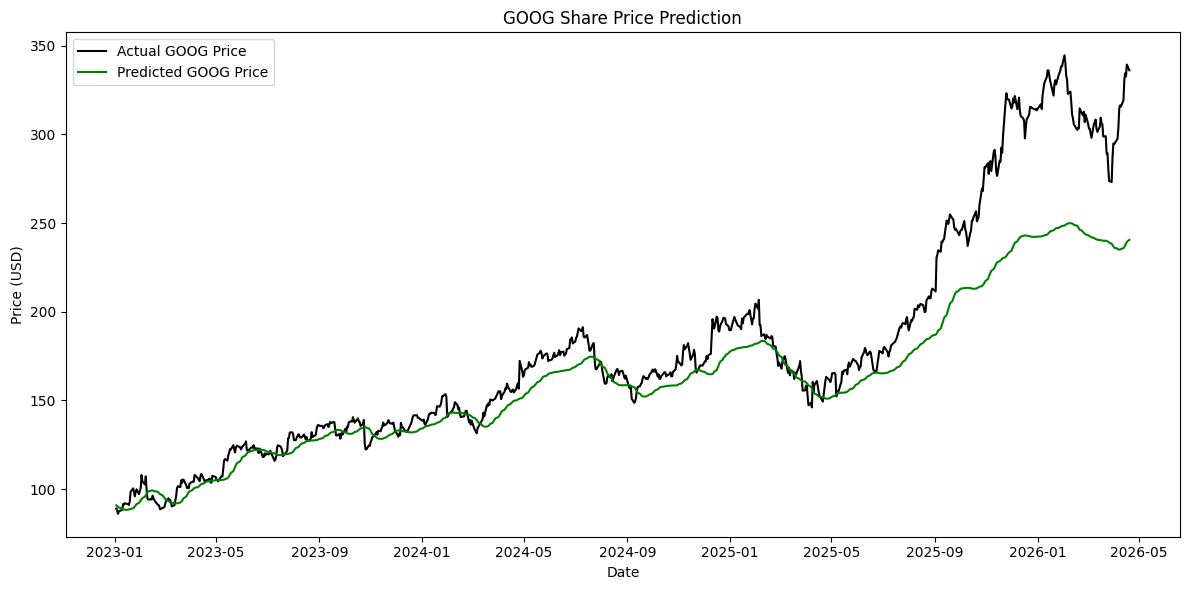

Next day predicted price for GOOG: $241.74
Last known close price: $336.20
Delta: $-94.46


In [5]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(test_dates, actual_prices, color="black", label=f"Actual {TICKER} Price")
plt.plot(test_dates, predicted_prices, color="green", label=f"Predicted {TICKER} Price")
plt.title(f"{TICKER} Share Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Next-day prediction
real_data = inputs_for_model[-PREDICTION_DAYS:, 0]
real_data = np.array([real_data])
real_data = np.reshape(real_data, (real_data.shape[0], real_data.shape[1], 1))

next_day_scaled = model.predict(real_data, verbose=0)
next_day_price = scaler.inverse_transform(next_day_scaled)[0][0]

print(f"Next day predicted price for {TICKER}: ${next_day_price:.2f}")
print(f"Last known close price: ${actual_prices[-1]:.2f}")
print(f"Delta: ${next_day_price - actual_prices[-1]:.2f}")